* DSC 530
* Final Project
* Andrew Booth

# Code Attribution

Title: DSC530 Final Project.  

Author: Andrew Booth.  

Date: 20 January 2026.  

Description: EDA on 2024-2025 Fantasy Premier League Statistics

In [1]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Machine learning - Preprocessing & Models
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans

# Model evaluation
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, 
    classification_report, confusion_matrix, fowlkes_mallows_score,
    silhouette_score
)

# Statistical testing
from scipy.stats import f_oneway, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Dimensionality reduction
from sklearn.decomposition import PCA

# Custom utilities (from course)
from ml_utils.regression import plot_residuals
from ml_utils.classification import plot_roc, confusion_matrix_visual

import datetime

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


ModuleNotFoundError: No module named 'ml_utils'

# Dataset Description

In [3]:
# Import dataset
ft = pd.read_csv('Fantrax 24_25 Data.csv')
print(ft)

                   Player Team Pos  RkOv    FPts    PPG  Ros% G1 Start    ADP  \
0           Mohamed Salah  LIV   F     1  716.25  19.36   100  checked    4.7   
1            Bryan Mbeumo  BRF   F     2  563.25  15.22   100  checked   43.4   
2             Cole Palmer  CHE   M     3  554.25  15.40   100  checked    3.5   
3         Bruno Fernandes  MUN   M     4  486.50  13.90   100  checked    5.6   
4           Matheus Cunha  WOL   F     5  464.25  14.51    99  checked   61.7   
..                    ...  ...  ..   ...     ...    ...   ...      ...    ...   
837        Mathis Amougou  CHE   M   838   -0.50  -0.50     0      NaN  300.0   
838          Frank Onyeka  BRF   M   839   -0.50  -0.25     0      NaN  300.0   
839  Jahmai Simpson-Pusey  MCI   D   840   -1.50  -0.75     0      NaN  300.0   
840           Ben Godfrey  IPS   D   841   -9.75  -3.25     0      NaN  300.0   
841           Ben Godfrey  IPS   D   841   -9.75  -3.25     0      NaN  300.0   

     Big 3 ADP  ...  ProjFP

    This dataset was created to support decision making for Fantrax Fantasy Premier League team selection.  It contains statistical information for over 800 English Premier League players across the full 38 match 2024–2025 season. 
    
    The dataset combines data from multiple sources.  Fantasy specific variables, such as overall rank (RkOv), fantasy points (Fpts), and average draft position (ADP), are sourced directly from the official Fantrax Fantasy Premier League platform.  Underlying performance metrics like, key passes, expected goals, expected assists, dribbles completed, and other advanced metrics are obtained from FBref, a publicly available football statistics website and then used to calculate variables which appear in the dataset, such as expected points per 90 (xPP90), and ghost points per 90 (gPP90).
    
    This dataset contains real life performance and fantasy related statistics for approximately 800 Premier League players observed across a single 38 match season (2024–2025).  The sample size is large enough to support exploratory data analysis, hypothesis testing, and predictive modeling, including regression, classification, and clustering techniques.  The dataset includes a combination of numerical variables (fantasy points, expected points per 90) and categorical variables (position, team), which are necessary for the planned analyses.  While the dataset represents only one season and therefore does not capture longer term trends, it is adequate for analysis of player performance within a consistent competitive context.
    
    The use of multiple data sources introduces potential biases and limitations.  Because the statistics are not all collected by a single organization, differences in data collection methodologies may exist.  Additionally, some variables are aggregated or derived by a third party (The Draft Society), which introduces an additional layer of processing.  This analysis assumes that the data collection and aggregation processes are accurate and consistently applied across players.  Any relevant variable definitions and transformations are described in detail in the Variable Description and Summary Statistics section.

# Data Cleaning and Preparation

In [158]:
# Df size
print("ORIGINAL DATAFRAME SIZE:")
print(ft.shape)

# Drop columns I won't use
ft2 = ft.drop(columns = ["Big 3 ADP", 
                        "Ros%", 
                        "G1 Start", 
                        "gPPS Form",
                        "23/24 gPPS", 
                        "Prev SP", 
                        "Prev FPts", 
                        "ProjFPts", 
                        "ProjGPts", 
                        "ProjMins", 
                        "ProjGS", 
                        "Big 3 Ros%", 
                        "ROS Rank", 
                        "+/-", 
                        "WARPS", 
                        "WAR", 
                        "Last Updated",
                        "Prev gPts"])

# Show columns kept in df
print("\n\nCOLUMNS KEPT IN DF:")
print(ft2.columns.tolist()) 

# Show df size
print("\n\nDATAFRAME SIZE AFTER DROPPING COLUMNS:")
print(ft2.shape)

# Sort df to only contian players with 1000 or more minutes played
ft3 = ft2.query('Mins >= 1000')

# Df size check
print("\n\nDATAFRAME SIZE AFTER MINUTES FILTER:")
print(ft3.shape)

# Examine missing values
print("\n\nEXAMINE MISSING VALUES:")
print(ft3.isna().sum())

# View values that are still missing
print("\n\nFIND WHERE VALUES ARE MISSING:")
print(ft3[ft3['xPP90'].isna()]) # 'xPP90 Δ' is reliant on xPP90 so we only need to look at one of the two

# Remove 8 players with missing data
ft4 = ft3.dropna().copy()

# Examine missing values
print("\n\nEXAMINE MISSING VALUES AFTER DROP:")
print(ft4.isna().sum()) 

# Df size check 
print("\n\nDATAFRAME SIZE AFTER MINUTES FILTER AND DROPPING MISSING VALUES:")
print(ft4.shape)

# Check for duplicates
print("\n\nCHECK FOR DUPLICATES:")
ft4.duplicated().sum()

# Add relevant rows for analysis
ft4['90s'] = ft4['Mins'] / 90
ft4['StdDev'] = ft4['Ceiling'] - ft4['PPS']
print("\n\nFINAL CLEANED DF:")
print(ft4)

# Double check that my additions didn't mess anything up
print("\n\nDOUBLE CHECK DF:")
ft4.isna().sum() 
ft4.duplicated().sum()

print("\n\nFINAL DF SIZE AFTER CLEANING:")
print(ft4.shape)

ORIGINAL DATAFRAME SIZE:
(842, 44)


COLUMNS KEPT IN DF:
['Player', 'Team', 'Pos', 'RkOv', 'FPts', 'PPG', 'ADP', 'Starts', '% Starts', '% SiS', 'PPS', 'Median PPS', 'Median - Mean', 'PP90', 'xPP90', 'xPP90 Δ', 'gPPS', 'gPP90', 'Ceiling', 'Floor', 'GACS%', 'Mins', 'Total SP', 'SPP90', 'SP%', 'SP Reliance%']


DATAFRAME SIZE AFTER DROPPING COLUMNS:
(842, 26)


DATAFRAME SIZE AFTER MINUTES FILTER:
(304, 26)


EXAMINE MISSING VALUES:
Player           0
Team             0
Pos              0
RkOv             0
FPts             0
PPG              0
ADP              0
Starts           0
% Starts         0
% SiS            0
PPS              0
Median PPS       0
Median - Mean    0
PP90             0
xPP90            8
xPP90 Δ          8
gPPS             0
gPP90            0
Ceiling          0
Floor            0
GACS%            0
Mins             0
Total SP         0
SPP90            0
SP%              0
SP Reliance%     0
dtype: int64


FIND WHERE VALUES ARE MISSING:
                Player Tea

    In this section we aim to clean and prepare the dataset for analysis.  The first thing I did was remove the columns in the dataset that were irrelevant to the analysis.  The columns removed were: "Big 3 ADP", "Ros%", "G1 Start", "gPPS Form", "23/24 gPPS", "Prev SP", "Prev FPts", "ProjFPts", "ProjGPts", "ProjMins", "ProjGS", "Big 3 Ros%", "ROS Rank", "+/-", "WARPS", "WAR", "Last Updated", and "Prev gPts".  The variables were removed for different reasons.  Some of them lacked clear documentation about their meaning or purpose, and there was no information from the source, such as "WARPS" and "WAR".  Other variables measured a singular week of data that were not relevant to the objective of our EDA, such as "G1 Start", "Prev gPts", and "Last Updated".  Other variables were aggregated from other sources with no understanding of how the aggregation was reached, such as "ProjFPts" and "ProjMins".  
    
    The next thing I did was examine missing values.  We can see that we have a significant amount of missing values in our "PP90", "xPP90", "xPP90 Δ", "gPPS", and "GPP90" columns.  The main reason for this is that a player might not have played enough minutes to earn fantasy points, and therefore the data is NaN.  To account for this, we will apply a minutes played filter, which will account for these missing values as well as make our data more reliable, since lower minutes played often leads to inflated per 90 numbers.  A common minutes played filter used in soccer data is 1000, so we will use that.  A threshold of 1000 minutes played correlates to about 29% of the available minutes in a 38 game season.  
    
    After filtering our dataset to players that played meaningful minutes, we now examine missing values.  We still found 8 missing values in the "xPP90" and "xPP90 Δ" columns, and after inspection, it appears that these values are missing for no reason.  These players played significant minutes, have no other data missing, yet these two columns are missing.  It must be noted that since "xPP90" and "xPP90 Δ" are reliant on each other, if one is missing, the other will be as well.  I decided to remove these 8 players from the analysis for a few reasons.  We are dealing with random missing values for 8 players out of 304, only 2.6% of our entire dataset.  Removing these players should not significantly impact our analysis even though they played significant minutes.  The cleaned dataset contains no duplicates.
    
    I decided to add 2 variables to our dataset.  First was "90s", which is a different way of visualizing "Mins" (total minutes played), by taking "Mins" and dividing it by 90.  Since a soccer game is 90 minutes long, 90s is a metric often used to easier identify how much a player played, by saying "If I took the total minutes a player played, how many full 90 minute games would they have played."  This metric would have also been used to aggregate "PP90" by The Draft Society.  "PP90" is different than "PPG" (points per game), because it shows us a much more realistic version of this statistic.  Imagine a player played 38 games as a substitute, being brought on in the 85th minute each time, and scored a total of 50 fantasy points.  This players "PPG" would be 1.32.  If we instead used "PP90" we would see a value of 23.7.  As we can see, the per 90 metrics aim to tell you what a player would hypothetically score if given a full 90 minutes to play, whereas per game metrics can undervalue a player that consistently performs well off the bench.  There is a place for both of these statistics!  The last variable I added was "StdDev" (standard deviation).  The Draft Society website tells us that "Ceiling" is calculated by "PPS" + "StdDev", but doesnt explicitly give us "StdDev".  So I found it by subracting "PPS" from "Ceiling".  "StdDev" is a very useful stat in this context because it tells us how consistent a player is with their point returns.

# Varaible Description and Summary Statistics

    After removal of variables, and addition of new variables, the dataset contains the following columns: "Player", "Team", "Pos", "RkOv", "FPts", "PPG", "ADP", "Starts", "% Starts", "% SiS", "PPS", "Median PPS", "Median - Mean", "PP90", "xPP90", "xPP90 Δ", "gPPS", "gPP90", "Ceiling", "Floor", "GACS%", "Mins", "Total SP", "SPP90", "SP%", "SP Reliance%", "90s", and "StdDev".  Before describing each variable, it is helpful to provide context on the fantasy point system, since several metrics are derived from these scoring rules.
    
    Fantasy points are achieved by players completing successful actions during games, with more influential actions being rewarded with more points.  Midfielders (M) and Forwards (F) operate on the same scale for fantasy points, while Defenders (D) and Goalkeepers (G) have their own scale.  The scales are defined below:


Goalkeepers:
| Action | Point Delta |
|--------|-------------|
| Goal | +10 |
| Penalty Kick Save | +8 |
| Assist | +7 |
| Clean Sheet | +6 |
| Key Pass | +2 |
| Shot on Target | +2 |
| Save | +2 |
| Successful High Claim | +1 |
| Tackle Won | +1 |
| Smother | +1 |
| Aerial Won | +1 |
| Interception | +1 |
| Successful Dribble | +1 |
| Effective Clearance | +0.25 |
| Disposession | -0.5 |
| Yellow Card | -2 |
| Goal Against | -2 |
| Own Goal | -5 |
| Red Card | -7 |


Defenders:
| Action | Point Delta |
|--------|-------------|
| Goal | +10 |
| Assist | +7 |
| Clean Sheet | +6 |
| Key Pass | +2 |
| Shot on Target | +2 |
| Penalty Kick Drawn | +2 |
| Accurate Cross (Not From A Corner) | +1 |
| Tackle Won | +1 |
| Blocked Shot | +1 |
| Aerial Won | +1 |
| Interception | +1 |
| Successful Dribble | +1 |
| Effective Clearance | +0.25 |
| Disposession | -0.5 |
| Yellow Card | -2 |
| Goal Against | -2 |
| Penalty Kick Missed | -4 |
| Own Goal | -5 |
| Red Card | -7 |


Midfielders/Forwards:
| Action | Point Delta |
|--------|-------------|
| Goal | +9 |
| Assist | +6 |
| Key Pass | +2 |
| Shot on Target | +2 |
| Penalty Kick Drawn | +2 |
| Clean Sheet | +1 |
| Accurate Cross (Not From A Corner) | +1 |
| Tackle Won | +1 |
| Blocked Shot | +1 |
| Aerial Won | +1 |
| Interception | +1 |
| Successful Dribble | +1 |
| Effective Clearance | +0.25 |
| Disposession | -0.5 |
| Yellow Card | -2 |
| Goal Against | -2 |
| Penalty Kick Missed | -4 |
| Own Goal | -5 |
| Red Card | -7 |


    Througout this exploratory analysis there will be soccer-specific, and Draft Society specific terms and concepts that might not be common knowledge.  I will define the most relevant terms to the analysis in a glossary below:

    
Glossary:
| Term | Definition |
|------|------------|
| Expected Goals (xG) | The probability that a shot will result in a goal based on historical data from similar shots.  Measured between (0 - 1) |
| Expected Assists (xA) | The likelihood that a pass will become a goal, based on the quality of the shot that follows it.  Measured between (0 - 1) |
| Key Pass (KP) | A pass that leads to a shot. |
| Set Piece| An attacking dead ball situation where the ball is put back into play under controlled conditions.  (Corner Kicks, Free Kicks, Penalty Kicks) |
| Ghost Points| Fantasy points a player earns that are not from Goals, Assists, or Clean Sheets.  So points earned from: Key passes, shots on target, interceptions, tackles won, aerials won, clearances, successful dribbles, dispossessions, and accurate crosses not from corners. |


    Now I will describe all the variables in our dataset below:


| Variable Name | Type | Description | Units/Scale|
|---------------|------|-------------|------------|
| Player | Categorical | Player Name | N/A |
| Team | Categorical | Abbreviated Team Name | N/A |
| Pos | Categorical | Player Primary Position | G, D, M, F |
| RkOv | Discrete | Ordered rank of players by total fantasy points earned | Ranking |
| FPts | Discrete | Total number of fantasy points earned | Fantasy Points |
| PPG | Continuous | Fantasy points per game ("FPts" / Games Played)| Fantasy Points |
| ADP | Continuous | (Average Draft Position): The average of what position the player was taken in all of the drafts held in Fantrax's database | Draft Position |
| Starts | Discrete | Number of Games Started | Starts |
| % Starts | Continuous | Percentage of Games Started | Percentage |
| % SiS | Continuous | (Started in squad): Percentage of Games Started when player was included in the matchday squad  Ex: If a player was injured and missed a game completely, that would not count against % Sis| Percentage |
| PPS | Continuous | The mean of a players fantasy point totals from the games they started ("FPts" / "Starts")| Fantasy Points |
| Median PPS | Discrete | The median of a players fantasy point totals from the games they started| Fantasy Points |
| Median - Mean | Continuous | ("Median PPS" - "PPS") | Fantasy Points |
| PP90 | Continuous | A players fantasy points per 90 minutes played ("FPts" / "90s") | Fantasy Points |
| xPP90 | Continuous | (Expected points per 90): The amount of fantasy points a player would be expected to get per 90 minutes based on underlying statistics.  The Draft Society does not disclose their exact formula, but they note that they into account expected goals (xG), expected assists (xA), and expected goals allowed for defenders and goalkeepers (xGA). | Fantasy Points |
| xPP90 Δ | Continuous | The difference between a players actual PP90 and their xPP90.  (PP90 - xPP90).  This statistic aims to visualize a players under/overperformance of their expected point output. | Fantasy Points |
| gPPS | Continuous | (Ghost Points Per Start): The mean of a players ghost point totals from the games they started. | Fantasy Points |
| gPP90 | Continuous | (Ghost Points Per 90): A players ghost points per 90 minutes played. | Fantasy Points |
| Ceiling | Continuous | Calculated by ("PPS + StdDev") A statistic created by The Draft Society that aims to tell us the upper limit of what a player could score. | Fantasy Points |
| Floor | Continuous | Calculated by ("PPS" - "StdDev") A statistic created by The Draft Society that aims to tell us the lower limit of what a player could score. | Fantasy Points |
| GACS% | Continuous | The percentage of points a player gets from goals, assist, and clean sheets. | Percentage |
| Mins | Discrete | The total number of minutes a player played. | Minutes |
| Total SP | Discrete | The total number of set pieces a player took. | Set Pieces |
| SPP90 | Continuous | The amount of set pieces a player took per 90 minutes.  ("Total SP" / "90s") | Set Pieces |
| SP% | Continuous | The percentage of a teams total set pieces that a player takes while they are on the field. | Percentage |
| SP Reliance% | Continuous | The percentage of a players fantasy points that came from set pieces | Percentage |
| 90s | Continuous | Total number of full 90 minutes a player played.  ("Mins" / 90) | 90s |
| StdDev | Continuous | The standard deviation of a players point totals | Fantasy Points |

In [152]:
# Make a df containing the numeric variables only 
numeric_df = ft4.select_dtypes(include = 'number')


# Create a df for summary statistics
summary_df = numeric_df.describe().T  # Get base summary statistics
summary_df["Skew"] = numeric_df.skew()  # Add skewness, kurtosis, and variance
summary_df["Kurtosis"] = numeric_df.kurt()
summary_df["Variance"] = numeric_df.var()

# Round decimals
summary_df = summary_df.round(2)

print("SUMMARY STATISTICS:\n")
print(summary_df)

SUMMARY STATISTICS:

               count     mean     std      min      25%      50%      75%  \
RkOv           296.0   159.02   97.79     1.00    77.75   152.50   231.25   
FPts           296.0   210.30  104.98    37.50   126.69   200.88   275.75   
PPG            296.0     7.04    2.71     1.63     5.02     6.89     8.62   
ADP            296.0   287.60  311.28     1.60    97.22   219.90   300.00   
Starts         296.0    24.49    8.11     8.00    18.00    25.00    31.00   
% Starts       296.0    64.44   21.32    21.00    47.00    66.00    82.00   
% SiS          296.0    75.40   20.47    23.00    61.00    79.50    93.25   
PPS            296.0     7.93    2.75     2.00     6.20     7.70     9.50   
Median PPS     296.0     6.97    2.72     0.50     5.00     6.80     8.40   
Median - Mean  296.0    -0.98    1.10    -4.50    -1.70    -0.90    -0.20   
PP90           296.0     8.87    3.02     2.80     6.88     8.40    10.70   
xPP90          296.0     8.90    2.69     2.90     7.20

   Here we can see the summary statistics for all numeric variables in our dataset.  These statistics provide insight into the central tendency (mean, median), spread (standard deviation, variance), and shape of the distributions (skewness, kurtosis) for each variable.
    Some interesting patterns emerge.  For example, ADP and the set piece metrics (Total SP, SPP90, SP%, SP Reliance%) are all right-skewed, meaning their distributions have a long tail on the high end. For ADP, this is expected, as most players in the dataset played significant minutes and were therefore likely to be higher draft picks.  For set piece metrics, the skew reflects the fact that teams typically rely on only two or three primary set piece takers, leaving the majority of players with low values in these variables.  Understanding skew and kurtosis is important for the rest of our analysis, as extreme skew or heavy tails can affect regression assumptions and other statistical methods.  

# Univariate Analysis

PLOT HISTOGRAMS FOR EACH NUMERIC VARIABLE:



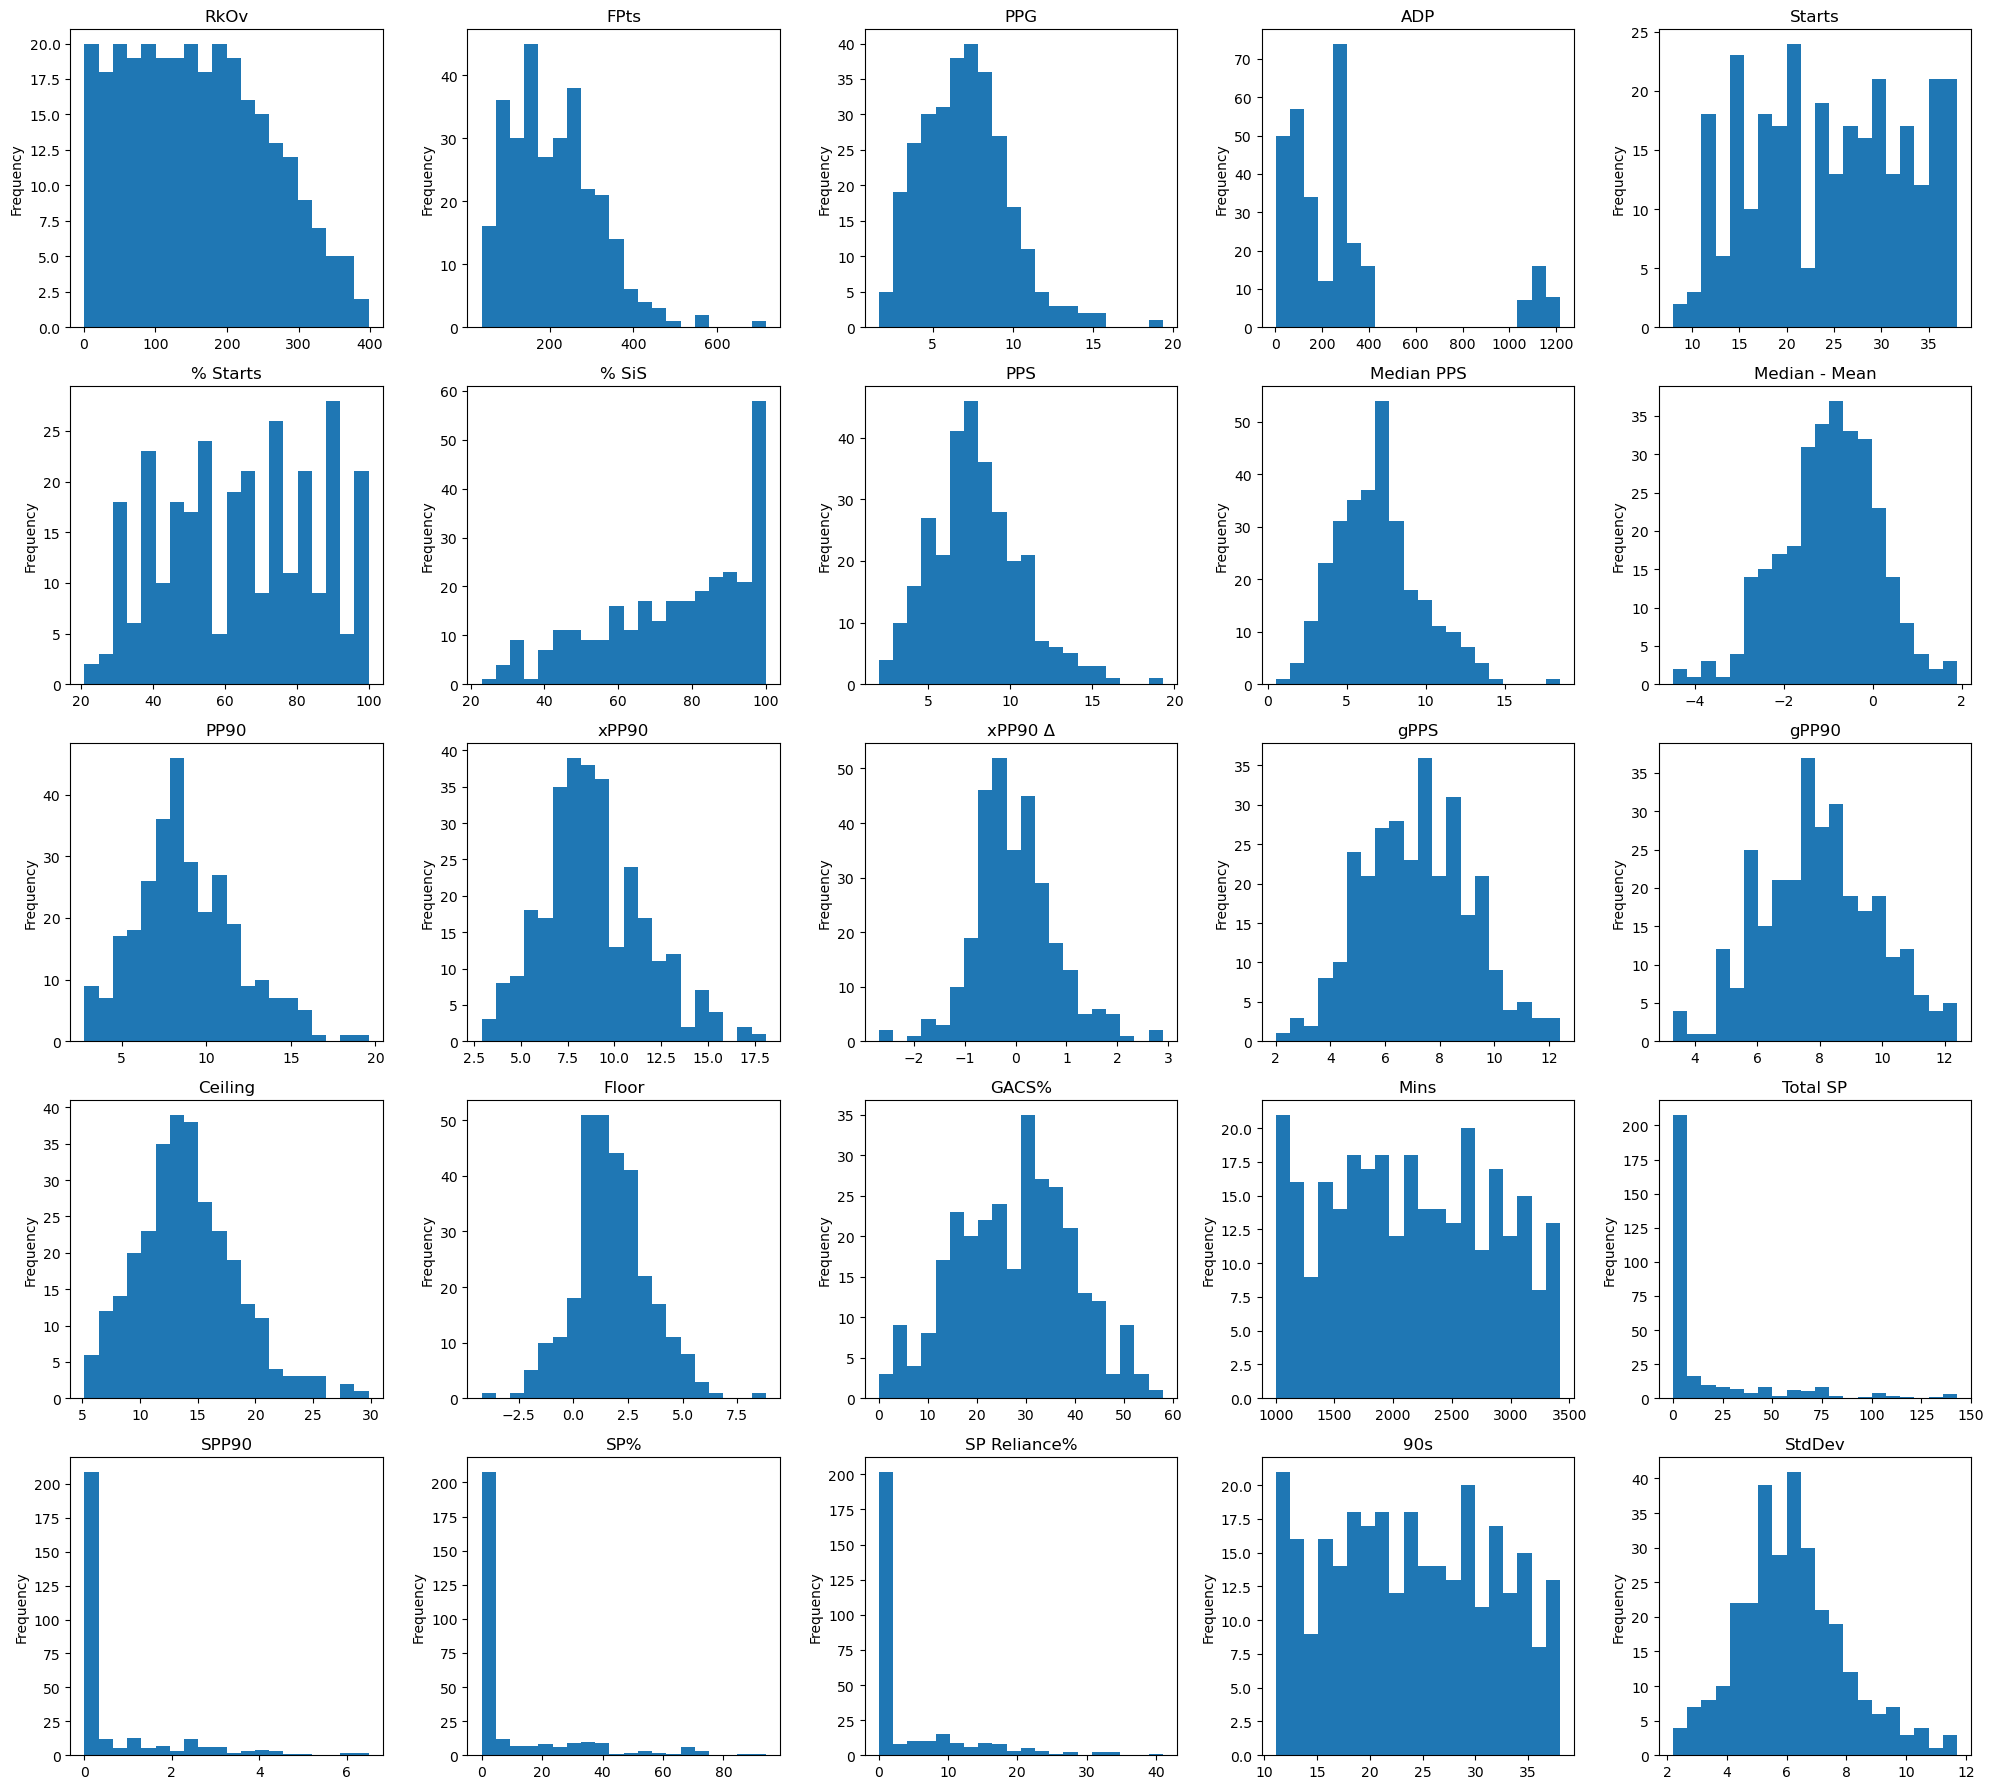



COUNT # OF PLAYERS IN EACH POSITION:

M    115
D    109
F     50
G     22
Name: Pos, dtype: int64

COUNT # OF PLAYERS FROM EACH TEAM:

TOT    17
SOU    17
LEI    17
EVE    17
IPS    16
AVL    16
MUN    16
ARS    15
CHE    15
NEW    14
LIV    14
CRY    14
BHA    14
FUL    14
BRF    14
WOL    14
BOU    14
WHU    14
MCI    13
NOT    11
Name: Team, dtype: int64


VIOLIN PLOTS FOR NUMERICAL DATA:



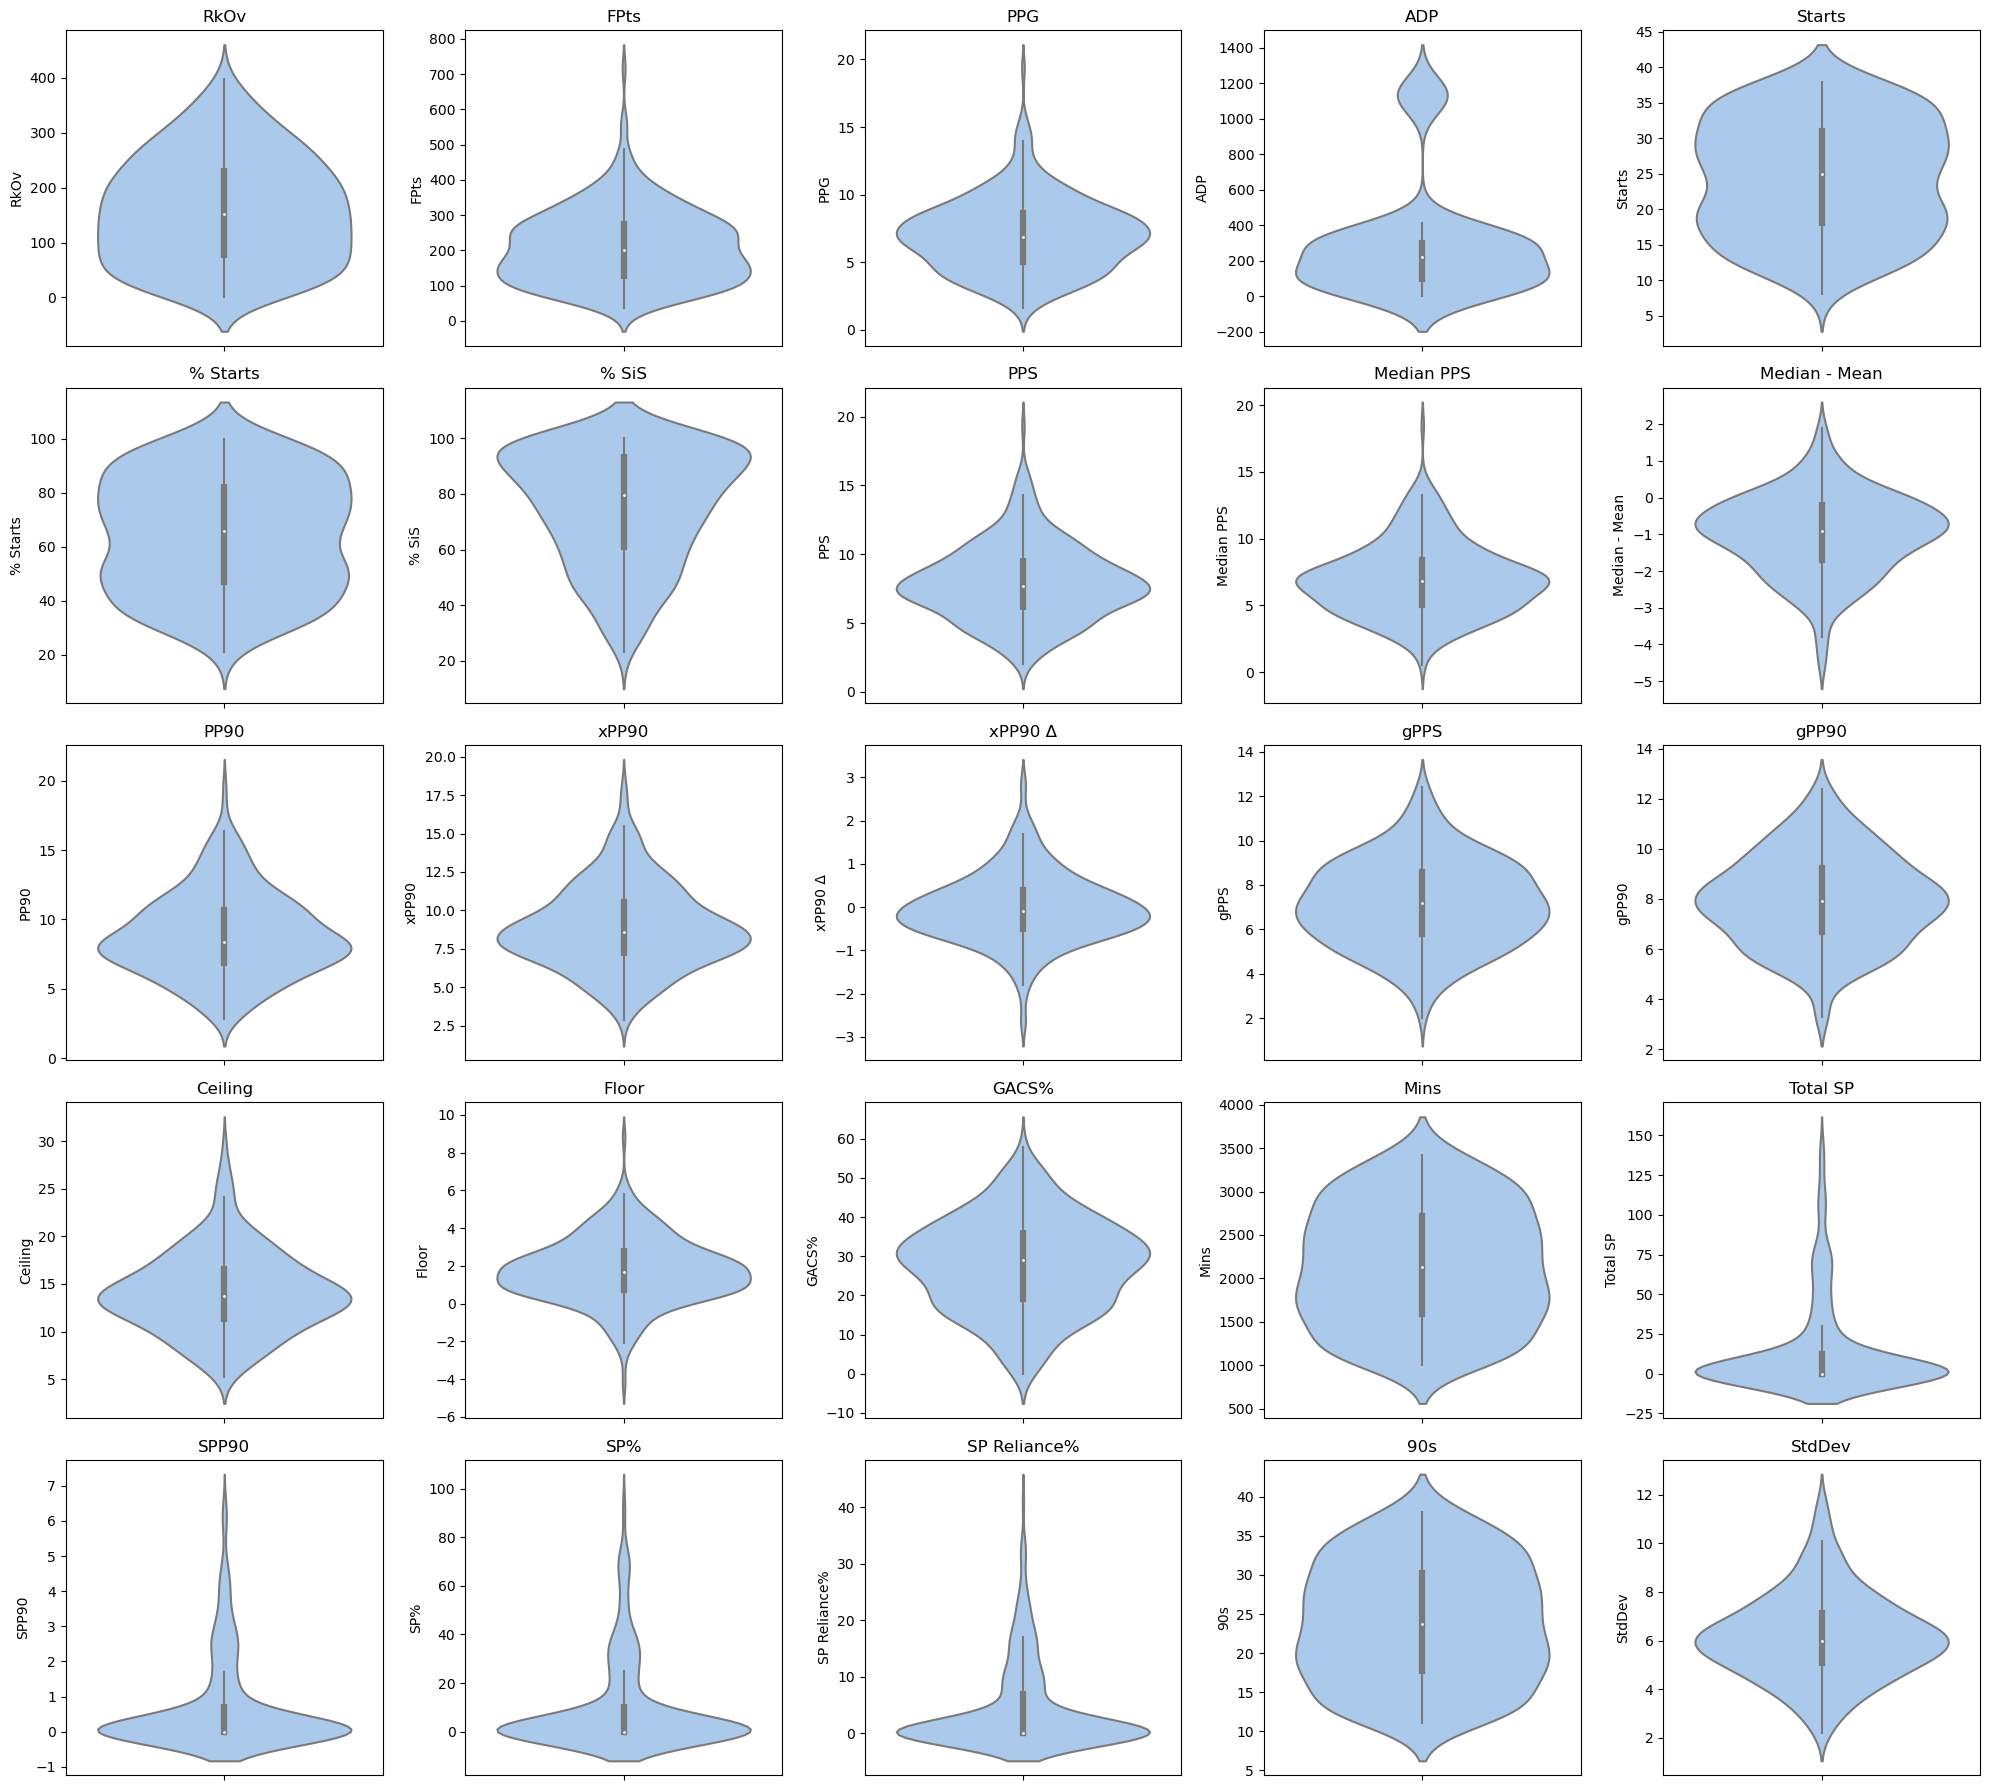

In [154]:
# Plot histograms of numeric variables
fig, axes = plt.subplots(5, 5, figsize = (20,18))

axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    axes[i].hist(numeric_df[col], bins = 20)
    axes[i].set_title(col)
    axes[i].set_ylabel("Frequency")

print("PLOT HISTOGRAMS FOR EACH NUMERIC VARIABLE:\n")
plt.tight_layout()
plt.show()


# Get counts for categorical variables
print("\n\nCOUNT # OF PLAYERS IN EACH POSITION:\n")
print(ft4["Pos"].value_counts())
print("\nCOUNT # OF PLAYERS FROM EACH TEAM:\n")
print(ft4["Team"].value_counts())


# Create boxlots for numerical data
fig, axes = plt.subplots(5, 5, figsize = (20,18))

axes = axes.flatten()

for i, col in enumerate(numeric_df.columns):
    sns.violinplot(y = numeric_df[col], inner = "box", palette = "pastel", ax = axes[i])
    axes[i].set_title(col)
    
print("\n\nVIOLIN PLOTS FOR NUMERICAL DATA:\n")
plt.tight_layout()
plt.show()

    Examining the histogram and violin plot distributions, we observe that most numeric variables are approximately normally distributed.  The skew identified in the summary statistics section is clearly visible in ADP and the set piece metrics.  An interesting observation with ADP is the gap in the data between 400 and 1000.  After further investigation, this gap was due to players not being drafted or joining the league after the drafts occurred, resulting in ADP values exceeding 1000.
    
    Some other distributions worth noting that were not highlighted in the summary statistics were "FPts", "PPG", "PPS", and % "SiS". For the point based metrics (FPts, PPG, PPS), most players fall within the normal range of the distribution, while a few outliers represent the elite point getters throughout the season.  For the % SiS distributions, they appear more left skewed than previously suggested in the summary statistics.  This skew is likely a result of the 1000 minute filter, as most of the players remaining in this dataset were key players for their teams.

# Bivariate Analysis

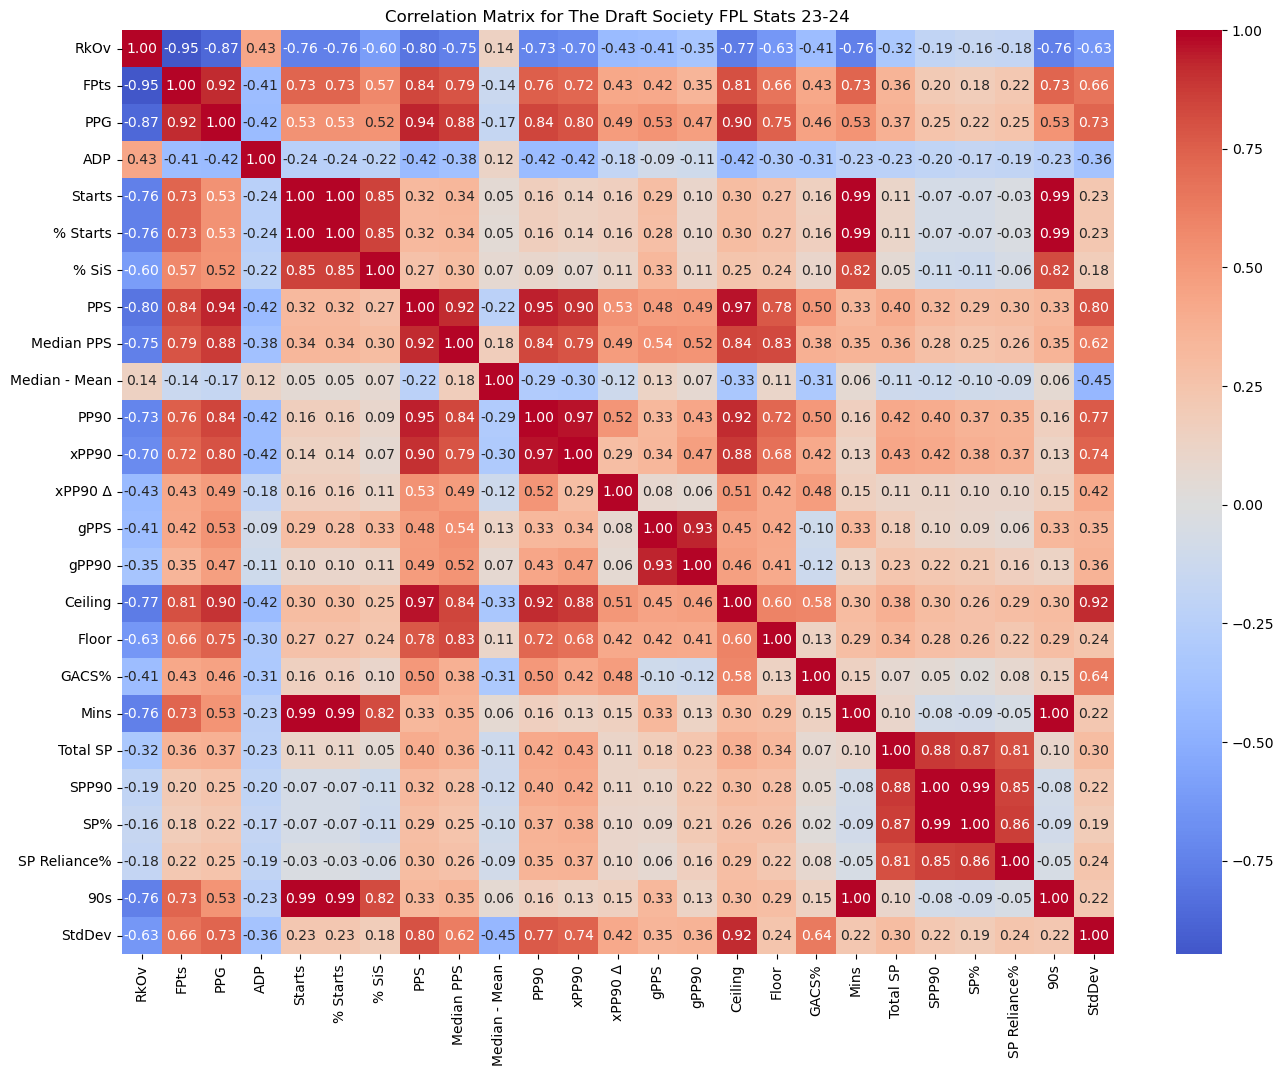



ALL STATS CORRELATION WITH 'FPTS':
FPts             1.000000
PPG              0.917524
PPS              0.838756
Ceiling          0.807959
Median PPS       0.791212
PP90             0.755238
Mins             0.730588
90s              0.730588
% Starts         0.728389
Starts           0.728380
xPP90            0.719541
Floor            0.662079
StdDev           0.658855
% SiS            0.574689
xPP90 Δ          0.428067
GACS%            0.425284
gPPS             0.416362
Total SP         0.360389
gPP90            0.353315
SP Reliance%     0.219009
SPP90            0.202408
SP%              0.180406
Median - Mean   -0.136394
ADP             -0.407924
RkOv            -0.946714
Name: FPts, dtype: float64


CORRELATION BETWEEN PP90 AND GPP90:
0.43459373603317586


PPG / MINS VS FPTS, BOTH VERY STRONG CORRELATIONS:


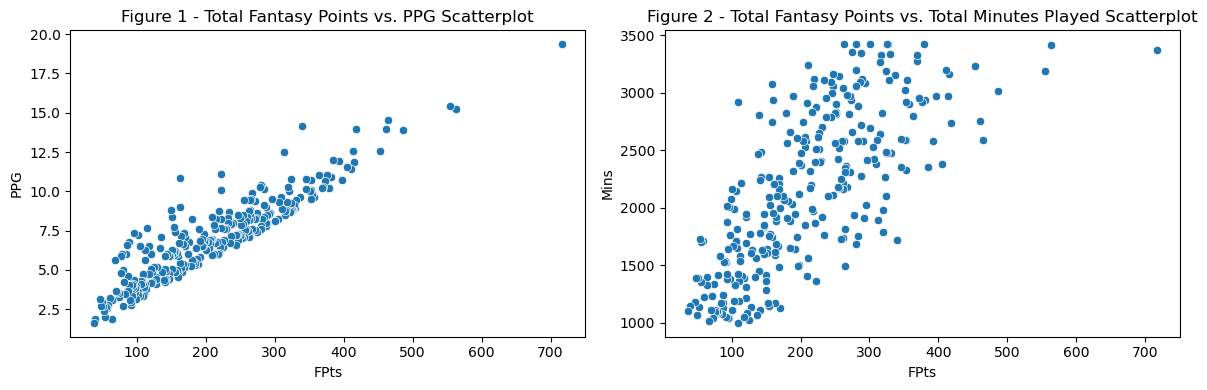



CEILING / FLOOR VS FPTS, CEILING BETTER CORRELATION:


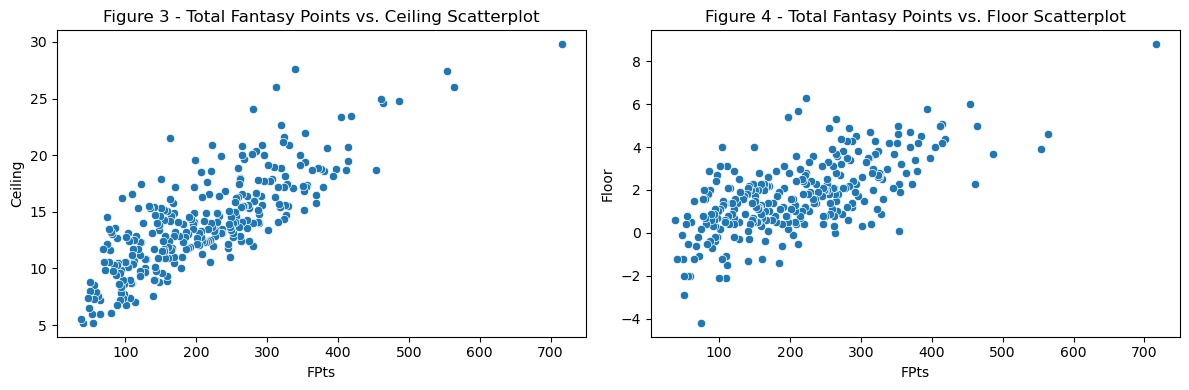



xPP90 / PP90 VS FPTS, PP90 BETTER CORRELATION:


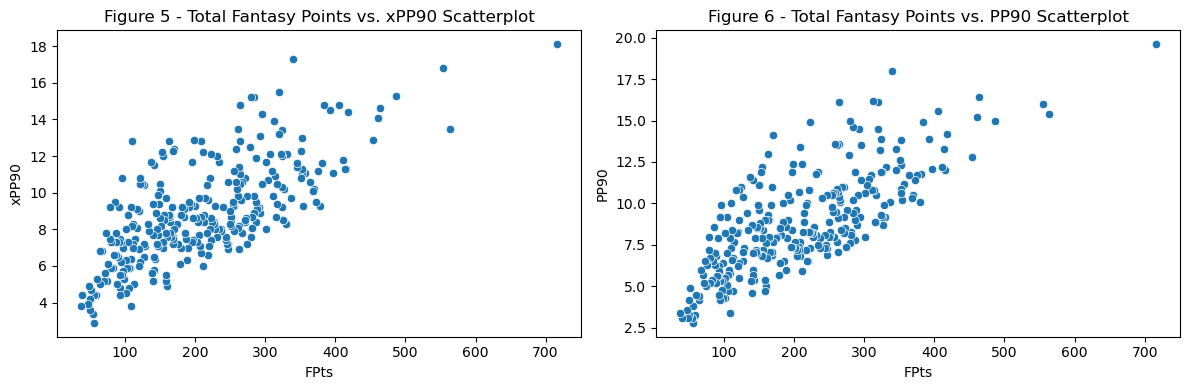



TOTAL SP VS FPTS / PP90 VS gPP90, UNDERWHEMING CORRELATIONS:


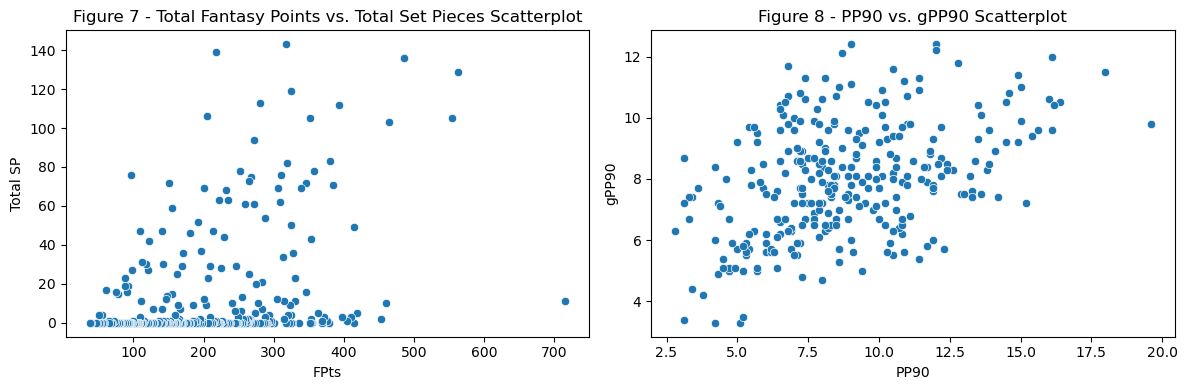



FIND TOP 20% OF SET PIECE TAKERS:
20.0


TOTAL FANTASY POINTS / PP90 BY SET PIECE %:


TOTAL FANTASY POINTS / PP90 BY POSITION VIOLIN PLOTS:


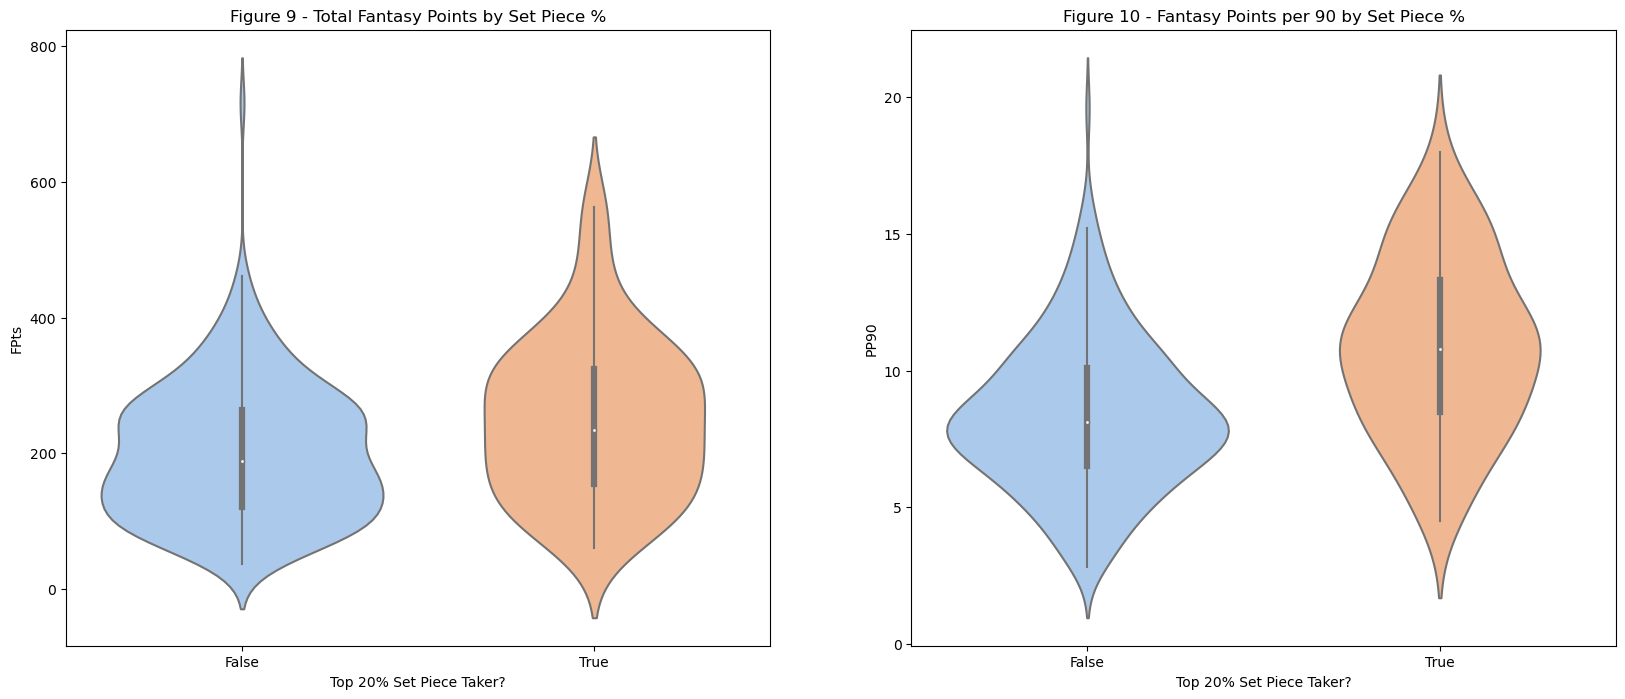

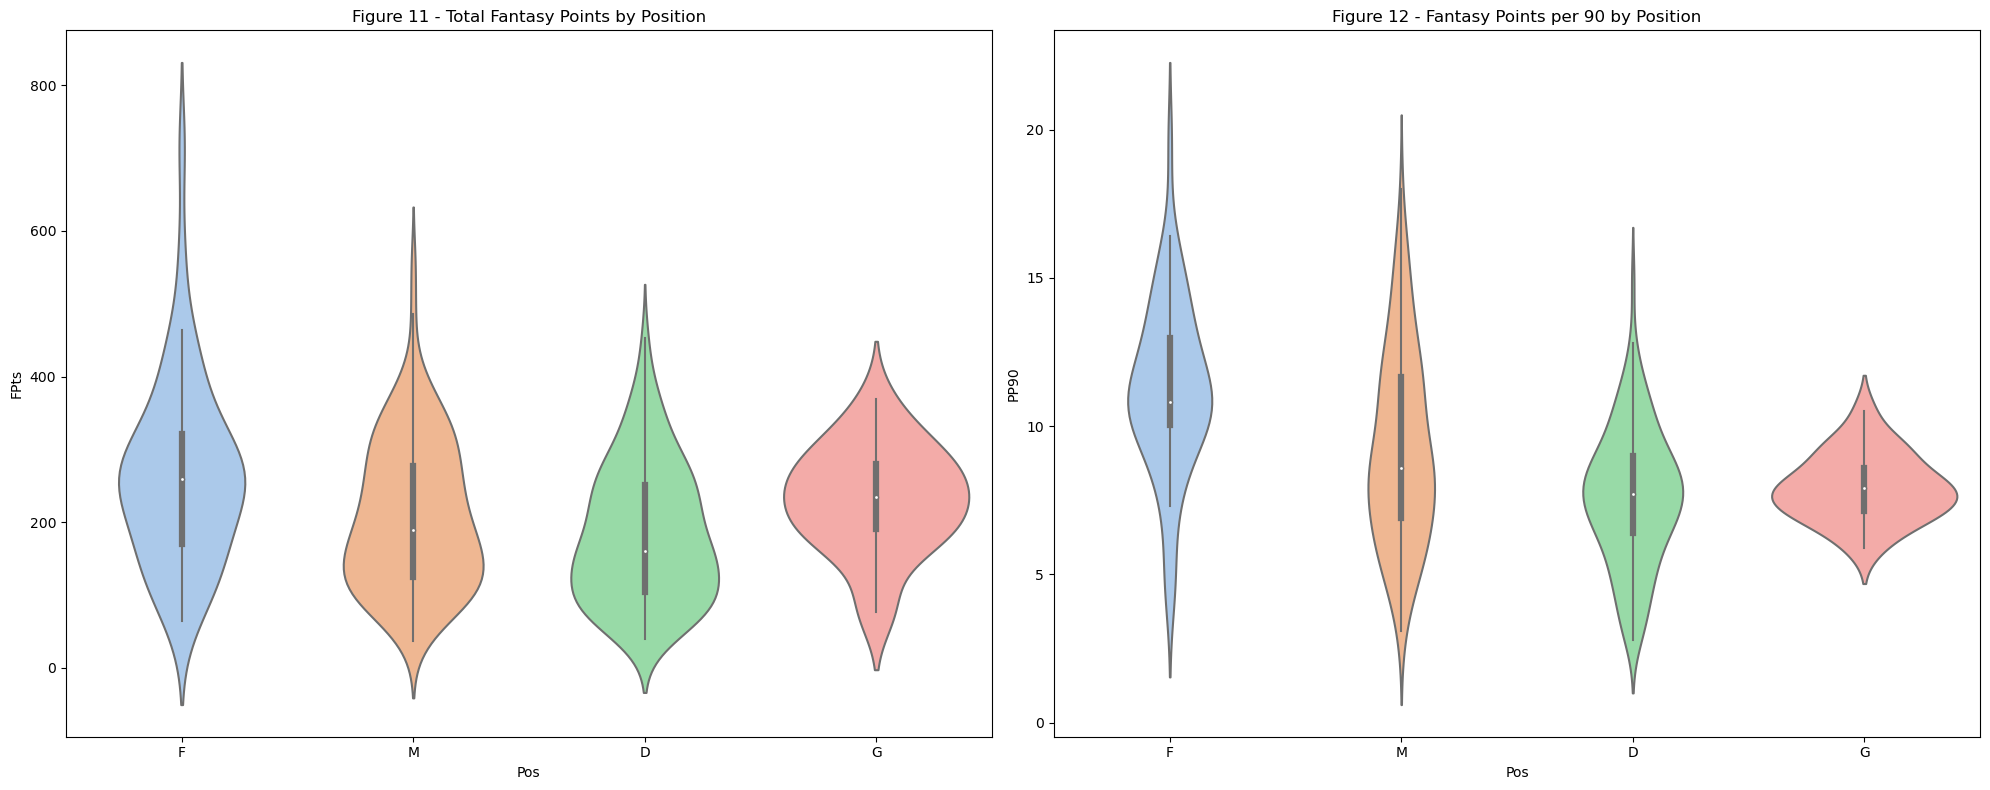

In [138]:
# Get correlation matrix
corr_summary = ft4.corr()

# Plot correlation matrix
plt.figure(figsize = (16,12))
sns.heatmap(
    corr_summary, 
    annot = True,
    fmt =".2f",
    cmap = 'coolwarm',
    center = 0)

plt.title('Correlation Matrix for The Draft Society FPL Stats 23-24')
plt.show()

# Find correlation with "FPts" 
fpts_corr = ft4.corr()["FPts"].sort_values(ascending = False)
print("\n\nALL STATS CORRELATION WITH 'FPTS':")
print(fpts_corr)

# Correlation between PP90 and gPP90
print("\n\nCORRELATION BETWEEN PP90 AND GPP90:")
print(ft4["PP90"].corr(ft4["gPP90"]))


# INTERESTING SCATTERPLOTS:
print("\n\nPPG / MINS VS FPTS, BOTH VERY STRONG CORRELATIONS:") 
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.flatten()

sns.scatterplot(x = ft4["FPts"], y = ft4["PPG"], ax = axes[0])
axes[0].set_title("Figure 1 - Total Fantasy Points vs. PPG Scatterplot")

sns.scatterplot(x = ft4["FPts"], y = ft4["Mins"], ax = axes[1])
axes[1].set_title("Figure 2 - Total Fantasy Points vs. Total Minutes Played Scatterplot")

plt.tight_layout()
plt.show()


print("\n\nCEILING / FLOOR VS FPTS, CEILING BETTER CORRELATION:")
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.flatten()

sns.scatterplot(x = ft4["FPts"], y = ft4["Ceiling"], ax = axes[0])
axes[0].set_title("Figure 3 - Total Fantasy Points vs. Ceiling Scatterplot")

sns.scatterplot(x = ft4["FPts"], y = ft4["Floor"], ax = axes[1])
axes[1].set_title("Figure 4 - Total Fantasy Points vs. Floor Scatterplot")

plt.tight_layout()
plt.show()


print("\n\nxPP90 / PP90 VS FPTS, PP90 BETTER CORRELATION:")
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.flatten()

sns.scatterplot(x = ft4["FPts"], y = ft4["xPP90"], ax = axes[0])
axes[0].set_title("Figure 5 - Total Fantasy Points vs. xPP90 Scatterplot")

sns.scatterplot(x = ft4["FPts"], y = ft4["PP90"], ax = axes[1])
axes[1].set_title("Figure 6 - Total Fantasy Points vs. PP90 Scatterplot")

plt.tight_layout()
plt.show()


print("\n\nTOTAL SP VS FPTS / PP90 VS gPP90, UNDERWHEMING CORRELATIONS:")
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.flatten()

sns.scatterplot(x = ft4["FPts"], y = ft4["Total SP"], ax = axes[0])
axes[0].set_title("Figure 7 - Total Fantasy Points vs. Total Set Pieces Scatterplot")

sns.scatterplot(x = ft4["PP90"], y = ft4["gPP90"], ax = axes[1])
axes[1].set_title("Figure 8 - PP90 vs. gPP90 Scatterplot")

plt.tight_layout()
plt.show()


# Do set pieces matter?
print("\n\nFIND TOP 20% OF SET PIECE TAKERS:")
print(ft4["SP%"].quantile(.80))

# Create new df for sp%
sp = ft4[["Player", "SP%", "PP90", "FPts"]].copy()

# Add column for players who take more than 20% of their teams set pieces 
sp["20%?"] = sp["SP%"] >= 20

# Violin plots for difference between two groups for FPts and PP90
print("\n\nTOTAL FANTASY POINTS / PP90 BY SET PIECE %:")
fig, axes = plt.subplots(1, 2, figsize = (20,8))
axes = axes.flatten()

sns.violinplot(x = sp["20%?"], 
               y = sp["FPts"], 
               inner = "box", 
               palette = "pastel", 
               ax = axes[0])
axes[0].set_title("Figure 9 - Total Fantasy Points by Set Piece %")
axes[0].set_xlabel("Top 20% Set Piece Taker?")

sns.violinplot(x = sp["20%?"], 
               y = sp["PP90"], 
               inner = "box", 
               palette = "pastel",
               ax = axes[1])
axes[1].set_title("Figure 10 - Fantasy Points per 90 by Set Piece %")
axes[1].set_xlabel("Top 20% Set Piece Taker?")

# Plot FPts and PP90 by position
print("\n\nTOTAL FANTASY POINTS / PP90 BY POSITION VIOLIN PLOTS:") 
fig, axes = plt.subplots(1, 2, figsize = (20,8))
axes = axes.flatten()

sns.violinplot(x = ft4["Pos"], 
               y = ft4["FPts"], 
               inner = "box", 
               palette = "pastel", 
               ax = axes[0])
axes[0].set_title("Figure 11 - Total Fantasy Points by Position")

sns.violinplot(x = ft4["Pos"], 
               y = ft4["PP90"], 
               inner = "box", 
               palette = "pastel",
               ax = axes[1])
axes[1].set_title("Figure 12 - Fantasy Points per 90 by Position")

plt.tight_layout()
plt.show()





    Using the correlation matrix we can examine which metrics are related in a significant way in order to gain insight from our data set.  Seeing as the goal of fantasy sports is to win by having the highest number of points, I think we should start by finding out what metrics highly correlate to "FPts".  When we run a correlation table looking at how all the stats are correlated to "FPts" we have some strong correlations.  
    
    Figures 1 and 2 - "PPS" and "PPG" have the highest correlation with "FPts" since these are the actual points scored by players aggregated by their games played.  Since they both measure the same thing, I plotted "PPG" only in figure 1 above.  "Mins" also has a very strong correlation with "FPts" suggesting that by just playing a lot of minutes you give yourself a chance to score well in Fantrax, which we can see plotted in figure 2.  
    
    Figures 3 and 4 - Ceiling, which is derived from "PPS" and "StdDev" has a strong correlation as well, and notably a correlation 0.15 higher than "Floor", suggesting that players with a high ceiling are more valuable than steady players with a high floor.  
    
    Figures 5 and 6 - "XPP90" also has a high correlation with "FPts", though less than "PP90", suggesting that while "expected" metrics do predict well, actual output remains supreme.
    
    Figures 7 and 8 - A common strategy by seasoned Fantrax players is to draft players that take a high amount of set pieces and ghost well.  However, as modeled in these plots, when we look at the correlation data, "Total SP" is only 0.36 correlated with "FPts" and "gPP90 is only 0.43 correlated with "PP90".  As a seasoned Fantrax player myself, these were surprising!  
    
    Figures 9 and 10 - I took a deeper look at the set piece correlation by finding the top 20% of set piece takers by percentage and plotting a violin plot of their "FPts" and "PP90" next to each other.  There doesn't seem to be a huge difference visually in "FPts", though the median for top 20% set piece takers is higher.  There does seem to be a bigger difference in "PP90" between the two groups however.  So, while "SP%" isn't highly correlated with "FPts", it's probably because there isn't enough volume of players who actually take set pieces.  Perhaps if you are one of the select few taking a large enough amount, you will score more "PP90".  We will examine this relationship further in the next section.

    Figure 11 - I examined the difference between player positions in order to gain insight on what group of players have the highest value on Fantrax.  When we look at the violin plot of "FPts" vs "Pos" we see that forwards tend to score the most "FPts", as well as having the most upside.  Suprisingly, goalkeepers had the second highest median for "FPts", despite having less upside than midfielders or defenders.  I hypothesize a big reason for this is the fact that goalkeepers rarely get subbed off, and teams only tend to play one goalkeeper during an entire season.  A goalkeeper that is the starter for their team will likely play all of their teams minutes, and as we've seen minutes correlate to total points.  
    
    Figure 12 - This plot shows "PP90" vs "Pos", to adjust for goalkeeper minutes share, and things look a bit more like we'd expect.  Forwards, by far, tended to score the most "PP90" with the most upside, midfielders the second most, with a large range of scoring, with goalkeepers and defenders scoring similarly overall, though defenders had a much larger range.  
    
    This data is telling me a few things.  One, if you can get the right forwards or midfielders, you are in good shape!  They have huge upside.  Two, selecting the right goalkeeper won't make a world of difference, considering there is only about a 6 point range in PP90 from best to worst.  Three, selecting the right midfielders is huge.  The range in midfield is likelt due to the fact that there are defensive minded midfielders that will score less, as well as attacking minded midfielders that will score more over the course of the season, and making that distinction is crucial.

# Hypothesis Testing

In [146]:
# SET PIECE COMPARISON:
# Look at mean FPts by set piece%
print("MEAN TOTAL FPTS BY SET PIECE %:")
print(sp.groupby("20%?")["FPts"].mean().sort_values(ascending = False))

# Create groups
top20 = sp[sp["20%?"] == True]["FPts"]
bottom80 = top20 = sp[sp["20%?"] == False]["FPts"]

# Run t-test
result = ttest_ind(top20, bottom80)
print("\n\nTOTAL FPTS BY SET PIECE % T-TEST RESULTS:")
print("T-Statistic =", result.statistic)
print("P-value =", result.pvalue)


# Look at mean PP90 by set piece%
print("\n\nMEAN PP90 BY SET PIECE %:")
print(sp.groupby("20%?")["PP90"].mean().sort_values(ascending = False))

# Create groups
top20_90 = sp[sp["20%?"] == True]["PP90"]
bottom80_90 = top20 = sp[sp["20%?"] == False]["PP90"]

# Run t-test
result = ttest_ind(top20_90, bottom80_90)
print("\n\nPP90 BY SET PIECE % T-TEST RESULTS:")
print("T-Statistic =", result.statistic)
print("P-value =", result.pvalue)



# TOTAL FPTS COMPARISON:
# Separate positions
gk = ft4[ft4["Pos"] == "G"]["FPts"]
d = ft4[ft4["Pos"] == "D"]["FPts"]
mf = ft4[ft4["Pos"] == "M"]["FPts"]
fwd = ft4[ft4["Pos"] == "F"]["FPts"]

# Look at mean differences between positons 
print("\n\nMEAN TOTAL FPTS BY POSITION:")
print(ft4.groupby("Pos")["FPts"].mean().sort_values(ascending = False))

# Run ANOVA to determine if different positions actually score differently:
f_stat, p_value = f_oneway(gk, d, mf, fwd)

print("\n\nTOTAL FPTS BY POSITION ANOVA RESULTS:")
print("F-Statistic =", f_stat)
print("P-value =", p_value)

# Run a tukey post-hoc to see which groups actually differ
tukey = pairwise_tukeyhsd(endog = ft4["FPts"], 
                          groups = ft4["Pos"], 
                          alpha = 0.05)

print("\n\nTOTAL FPTS BY POSITION TUKEY TEST:")
print(tukey)


# PER 90 COMPARISON:
# Separate positions
gk90 = ft4[ft4["Pos"] == "G"]["PP90"]
d90 = ft4[ft4["Pos"] == "D"]["PP90"]
mf90 = ft4[ft4["Pos"] == "M"]["PP90"]
fwd90 = ft4[ft4["Pos"] == "F"]["PP90"]

# Look at mean differences between positons 
print("\n\nMEAN PP90 BY POSITION:")
print(ft4.groupby("Pos")["PP90"].mean().sort_values(ascending = False))

# Run ANOVA to determine if different positions actually score differently per 90:
f_stat, p_value = f_oneway(gk90, d90, mf90, fwd90)

print("\n\nPP90 BY POSITION ANOVA RESULTS:")
print("F-Statistic =", f_stat)
print("P-value =", p_value)

# Run a tukey post-hoc to see which groups actually differ per 90
tukey = pairwise_tukeyhsd(endog = ft4["PP90"], 
                          groups = ft4["Pos"], 
                          alpha = 0.05)

print("\n\nPP90 BY POSITION TUKEY TEST:")
print(tukey)

MEAN TOTAL FPTS BY SET PIECE %:
20%?
True     249.717213
False    200.071277
Name: FPts, dtype: float64


TOTAL FPTS BY SET PIECE % T-TEST RESULTS:
T-Statistic = 0.0
P-value = 1.0


MEAN PP90 BY SET PIECE %:
20%?
True     10.852459
False     8.356596
Name: PP90, dtype: float64


PP90 BY SET PIECE % T-TEST RESULTS:
T-Statistic = 6.098261481725811
P-value = 3.36707612359134e-09


MEAN TOTAL FPTS BY POSITION:
Pos
F    263.915000
G    230.965909
M    208.517391
D    183.422018
Name: FPts, dtype: float64


TOTAL FPTS BY POSITION ANOVA RESULTS:
F-Statistic = 7.488164184850781
P-value = 7.6070433214903e-05


TOTAL FPTS BY POSITION TUKEY TEST:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     D      F   80.493  0.001   35.6179  125.368   True
     D      G  47.5439 0.1901  -13.8628 108.9506  False
     D      M  25.0954 0.2539  -10.0256  60.2164  False
     F      G -32.94

    Since we saw potential differences in the "FPts" and "PP90" by players who were in the top 20% of set piece takers and those who were not, we explored this further in this section.  When we look at total fantasy points, we see a mean difference of about 50 more points over the course of the year for players who were in the top 20% of set piece takers.  However, when we run a t-test, we find no significant difference between the groups (t-statistic = 0, p-value = 1), meaning the difference could just be from variance.  When we looked at "PP90" instead, we once again saw a mean difference of about 2.4 more PP90 for a top 20% set piece taker, but this time there was a significant difference between the two groups in our t-test (t-statistic = 6.10, p-value = 0.0000000034).  We can say that while "SP%" and "FPts" aren't super correlated, if you are a top 20% set piece taker, you tend to score more "PP90" than players who are not.
    
    Since we saw a visual difference between "FPts" by positon and "PP90" by position in our violin plots, we should explore this data further.  When we look at the differences between the mean of each position, we see that F > G > M > D.  To explore further we ran an ANOVA to see if there actually is a significant difference between groups.  Our null hypothesis will be that all positions score the same, and our alternative hypothesis will be there is a difference between at least one of the positions in terms of total fantasy points scored.  In our ANOVA for "FPts" between positons we had an F-statistic of 7.49 and a significant p-value of 0.000076, meaning that we reject our null hypothesis.  When we run a tukey post-hoc test, we found a significant difference between defenders and forwards, and between forwards and midfielders.  Forwards scored 80.49 more points on average than defenders (p-value = 0.001, and forwards also scored 55.4 more points on average than midfielders (p-value = 0.0078).  This analysis confirms that forwards get more total points over the course of a season than defenders and midfielders.  
    
    I also wanted to run an ANOVA between the "PP90" by position, since visually there was an even more clear difference in our violin plots from above.  As we can see, our mean differences appear less extreme, and are also ordered differently.  Here we have F > M > G > D, with a very small difference between defenders and goalkeepers per 90.  Once again, I believe this is due to the fact that goalkeepers play more minutes than most outfielders.  While they tend to score more total points than midfielders or defenders in a season, they tend to get less per 90 than midfielders, and about the same as defenders.  We ran an ANOVA again to explore further.  Our null hypothesis will be that all positions score the same per 90, and our alternative hypothesis will be that there is a difference between at least one of the positions in terms of "PP90".  Our ANOVA returned an F-statistic of 21.71, and a significant p-value of 0.000000000001, meaning that we reject our null hypothesis.  When we ran a tukey post-hoc test, we found significant differences between mulitple groups.  Forwards outscored defenders by 3.64 PP90 (p-value = 0.001).  Midfielders also outscored defenders by 1.61 PP90 (p-value = 0.001).  Forwards outscored goalkeepers by 3.32 PP90 (p-value = 0.001).  Finally, forwards outscored midfielders by 2.02 PP90 (p-value of 0.001).  This analysis confirms that forwards are the most valuable players per 90 in Fantrax, outscoring every other position.  We can also confirm that midfielders outscore defenders per 90.

# Regression Analysis

MODEL COEFFICENTS:
                       0
 0.000000         Starts
 0.039323       % Starts
 0.078333          % SiS
 0.000000     Median PPS
-0.034515  Median - Mean
 0.043637        xPP90 Δ
-2.583091           gPPS
 2.220294          gPP90
 2.228193        Ceiling
 0.958486          Floor
 0.017181          GACS%
-0.000000           Mins
-0.060433       Total SP
 0.060673          SPP90
 0.049183            SP%
-0.037941   SP Reliance%
-0.000000            90s
 0.000000         StdDev



MODEL INTERCEPT: 8.990540540540543


MODEL R² = 0.9811634434551816


MODEL RMSE = 0.43650208950559


CROSS VALIDATION:
R² for each fold: [0.98191409 0.98684416 0.94789316 0.92958409 0.90000917]
Mean R²: 0.9492489358209676
Std: 0.03253770649360711


PLOT RESIDUALS:


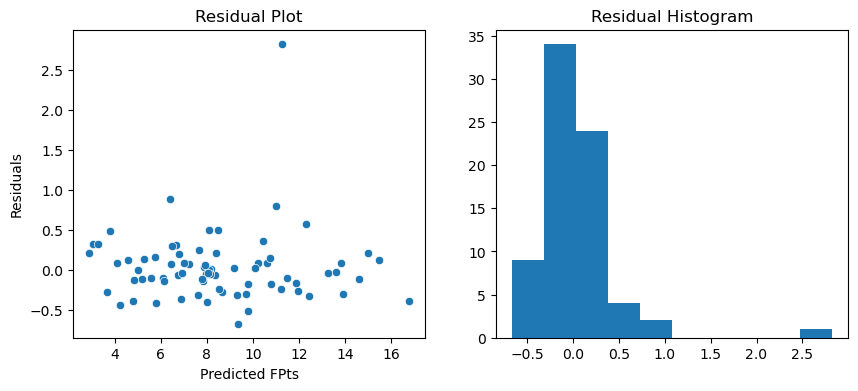

In [9]:
# Use Lasso CV to build a regression for PP90
# Remove predictors that are categorical, irrelevant, or transformations of PP90
X = ft4.drop(columns = ["FPts", "PP90", "Team", "Player", "Pos", "xPP90", "RkOv", "PPG", "PPS", "ADP"])
y = ft4["PP90"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 1)

pipeline = Pipeline([
    ("scaler", StandardScaler()),    
    ("lasso", LassoCV(cv = 10, max_iter = 10000, random_state = 1)) 
])

pipeline.fit(X_train, y_train)

# Get model coefficents and intercept
lasso_coef = pd.DataFrame(X.columns, pipeline.named_steps["lasso"].coef_)
print("MODEL COEFFICENTS:")
print(lasso_coef)

print("\n\n")
print("MODEL INTERCEPT:", pipeline.named_steps['lasso'].intercept_)


# Predict y using X test data to see how well model works
y_pred = pipeline.predict(X_test)

# Find r2 and rmse
r2 = r2_score(y_test, y_pred)

print("\n\nMODEL R² =", r2)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n\nMODEL RMSE =", rmse)

# Cross validate to make sure model isn't overfitting, mean r2 should be similar to y_pred r2
print("\n\nCROSS VALIDATION:")
scores = cross_val_score(pipeline, X, y, cv = 5, scoring = "r2")
print("R² for each fold:", scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())


# Get residuals
residuals = y_test - y_pred

# Plot residuals
fig, axes = plt.subplots(1, 2, figsize = (10, 4))

sns.scatterplot(x = y_pred, y = residuals, ax = axes[0])
axes[0].set_xlabel("Predicted FPts")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot")

axes[1].hist(residuals)
axes[1].set_title("Residual Histogram")

print("\n\nPLOT RESIDUALS:")
plt.show()

    In this section I aimed to predict "PP90", using the variables in my dataset.  I chose linear regression because earlier analysis suggested linear relationships between the predictors and the target.  Given the number of predictors and potential multicollinearity, I used LassoCV, which optimizes the regression line while shrinking irrelevant coefficients to zero, leaving only the most impactful features.  I also chose to uses "PP90" as my target variable instead of "FPts" because it standardizes the target variable, adjusting for minutes played.  The model was trained on 75% of the data.  From the training data we end up with a line:  PP90 = 0.04(% Starts) + 0.08(% SiS) - 0.03(Median - Mean) + 0.04(xPP90 Δ) - 2.58(gPPS) + 2.22(gPP90) + 2.23(Ceiling) + 0.96(Floor) + 0.02(GACS%) - 0.06(Total SP) + 0.06(SPP90) + 0.05(SP%) - 0.04(SP Reliance%) + 8.99.  When I used the model to predict PP90 on our test data, it performed really well, with a rmse of 0.44, and an r-squared of 0.98, meaning our model predicted "PP90" to an accuracy of under 0.5 points and explained 98% of the variance in PP90.  To make sure our model isn't overfitted, we did a cross validation with k-fold cross validation, where we also found a very high r-squared of 0.95.  This means our model generalizes very well.  The residual plots are approximately normally distributed, validating linear regression assumptions.  One outlier exists where the model was off by about 2.5 PP90, but predictions are accurate across the majority of players.

# Clustering Analysis

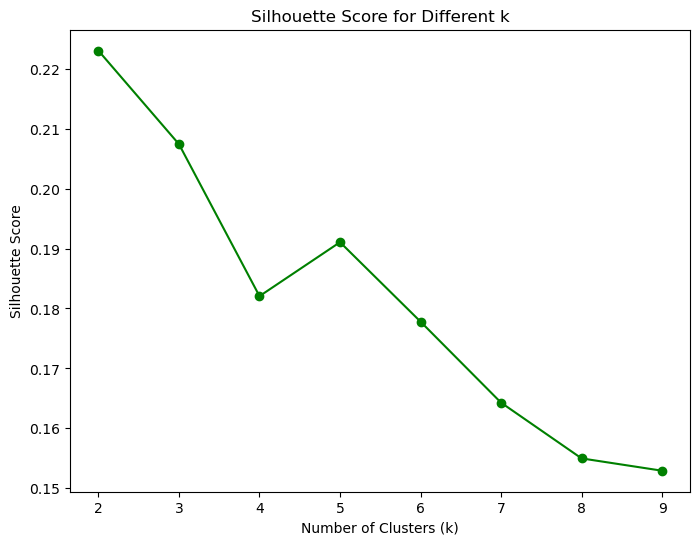



MEAN DIFFERENCES BETWEEN CLUSTER ATTRIBUTES:
               PPG   % Starts      % SiS  Median PPS  Median - Mean   xPP90 Δ  \
clusters                                                                        
0         4.787368  50.150376  62.879699    4.992481      -0.854135 -0.377444   
1         8.882454  76.104294  85.619632    8.585276      -1.079141  0.255828   

             gPP90    Ceiling     Floor      GACS%     SPP90  SP Reliance%  \
clusters                                                                     
0         7.256391  10.902256  0.736842  22.744361  0.462406      3.082707   
1         8.554601  16.704908  2.582822  31.938650  0.874233      5.423313   

                90s    StdDev  
clusters                       
0         18.741855  5.078195  
1         28.098705  7.060123  


In [72]:
# Clustering analysis
# Create predictors avoiding redundancy
X = ft4.drop(columns = ["Team", "Pos", "Player", "xPP90", "PPS", "FPts", "RkOv", "ADP", "Mins", 
                        "SP%", "Total SP", "gPPS", "Starts", "PP90"])
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use PCA to flatten high dimensions
pca = PCA(n_components = 5, random_state = 1)  # reduce to 5 dimensions
X_pca = pca.fit_transform(X_scaled)


# Run silhouette score to find optimal K
K_range = range(2, 10)

silhouette = []

for k in K_range:
    kmeans = KMeans(n_clusters = k, n_init = 10, random_state = 1)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

plt.figure(figsize = (8,6))
plt.plot(K_range, silhouette, 'o-', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.show()


# Optimal k = 2 (no meaningful clustering) 
kmeans = KMeans(n_clusters = 2, random_state = 1, n_init = 10)
clusters = kmeans.fit_predict(X_pca)

cluster_df = pd.DataFrame(X)
cluster_df["clusters"] = clusters

# Look at mean differences between cluster attributes (not meaningful)
print("\n\nMEAN DIFFERENCES BETWEEN CLUSTER ATTRIBUTES:")
print(cluster_df.groupby('clusters').mean())

    In this section we applied clustering techniques to see if the data naturally clustered.  I tried a few different methods.  First I tried using various attributes with k = 4 to see if players clustered naturally by position.  This was largely unsuccessful as crosstab analysis showed there was really no separation between positions.  I then focused on trying to find an optimal silhouette score to see if our data clustered better at a different k value.  As we can see, our highest silhouette score was 0.22 with 2 clusters, which outlines our inability to gather meaningful insight from clustering our data.  We observed the mean differences between the two clusters, and the only insight I can find is that cluster 1 contains players who played more and had better point metrics than those in cluster 0.  I would imagine that if I had more of the raw data that The Draft Society data is derived from there would be more meaningful clusters created.  Helpful data for further future analysis woudl be: key passes, shots, shots on target, saves, dribbles, tackles, and other in game actions.    

# Classification Analysis



MODEL RESULTS:
Logistic Regression: 0.7342424242424243
Decision Tree: 0.5494949494949495
Random Forest: 0.6393939393939394
Gradient Boosting: 0.6264646464646464


NOTE CLASS IMBALANCE!!:
M    115
D    109
F     50
G     22
Name: Pos, dtype: int64


FEATURE IMPORTANCE DF:
          feature  importance
6           gPP90    1.666531
9           GACS%    0.837736
7         Ceiling    0.573354
3      Median PPS    0.510209
2           % SiS    0.489177
0             PPG    0.488846
13         StdDev    0.454235
8           Floor    0.421984
11   SP Reliance%    0.393502
10          SPP90    0.369990
12            90s    0.369819
4   Median - Mean    0.340598
5         xPP90 Δ    0.309226
1        % Starts    0.272739


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           D       0.76      0.93      0.83        27
           F       0.88      0.58      0.70        12
           G       1.00      0.17      0.29         6
           M       0.84      0.93 

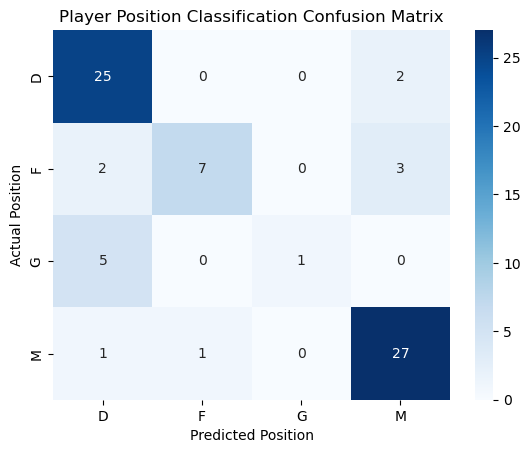

In [147]:
# Classify 
X = ft4.drop(columns = ["Team", "Player", "Pos", "xPP90", "PPS", "FPts", "RkOv", "ADP", "Mins", 
                        "SP%", "Total SP", "gPPS", "Starts", "PP90"])

y = ft4["Pos"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 1, stratify = y) # stratify y because clases are imbalanced

# Test multiple models
models = {
    "Logistic Regression": LogisticRegression(max_iter = 2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators = 200, random_state = 1),
    "Gradient Boosting": GradientBoostingClassifier()}

results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv = 5,
        scoring = "accuracy"
    )

    results[name] = scores.mean()

print("\n\nMODEL RESULTS:")
for model, score in results.items():
    print(f"{model}: {score}")


print("\n\nNOTE CLASS IMBALANCE!!:")
print(ft4["Pos"].value_counts())


# Run best model (LogisticRegression)
best_pipe = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", LogisticRegression())
])

# Fit model on training data
best_pipe.fit(X_train, y_train)

# Predict classes on testing data
y_pred = best_pipe.predict(X_test)

# Find feature importance
coef = best_pipe.named_steps["model"].coef_  
features = X.columns
classes = best_pipe.named_steps["model"].classes_

importance = np.mean(np.abs(coef), axis = 0)
importance_df = pd.DataFrame({"feature": features, 
                              "importance": importance
                             }).sort_values("importance", ascending = False)

print("\n\nFEATURE IMPORTANCE DF:")
print(importance_df)

print("\n\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# Examine confusion matrix 
cm = confusion_matrix(y_test, y_pred)

class_labels = ["D", "F", "G", "M"] # Label classes

# Create a heatmap for visualization
sns.heatmap(cm, 
            annot = True, 
            fmt = 'd', 
            cmap = 'Blues', 
            xticklabels = class_labels, 
            yticklabels = class_labels)
plt.xlabel("Predicted Position")
plt.ylabel("Actual Position")
plt.title("Player Position Classification Confusion Matrix")
plt.show()

    For the classification section of this EDA, I aimed to classify players by their position using their Draft Society and Fantrax statistics.  The first thing I did was identify my predictors, making sure to avoid redundancy, and identify my target variable which was "Pos".  I then tested 4 models: logistic regression, decision tree, random forest, and gradient boosting for accuracy and decided to work with the most accurate one, logistic regression.  
    
    I trained the model on 75% of the data, tested on the remaining 25%, and evaluated the model.  It is first important to note that our classes were unbalanced.  Our position count is: midfielders (M) = 115, defenders (D) = 109, forwards (F) = 50, and goalkeepers (G) = 22.  This imbalance is represented in our classification report, as the model tended to identify G and F much less compared to M and D when we look at recall.  G had a recall of only 0.17, and F 0.58, which was in contrast to the high recall of 0.93 for both D and M.  Admittedly, the model had a higher chance of picking a D or M even if it chose at random, as well as the fact that it had more D and M data to learn from.  
    
    Looking at precision, our model did well.  Despite the fact that the model had trouble identifying G and F it was extremely accurate when it did (100% precision for G, and 88% precision for F).  The model was also pretty precise predicting M and D (84% precision for M, and 76% precision for D).  
    
    When we evaluate our F-scores, meant to be a balanced score for a situation with imbalanced classes, G is our main concern with a score of 0.29.  Our model simply didn't recognize G well enough, only predicting it one time, despite the fact that when it did choose that one it was accurate.  The other positions all had respectable F-scores (D = 83%, F = 70%, M = 89%). 
    
    Once again, having more underlying data would perhaps make this classification fit much better.  In the real world of soccer data analysis, players are more distinguished by underlying stats like passes, shots, dribbles, and other metrics.  For a model that is only using Fantrax and Draft Society data, I was suprised to see this model work as well as it did.

# Limitations and Assumptions

    Like we spoke about in the introduction, the main limitation and bias in this EDA is the fact that a lot of our data is scraped from a third party source (The Draft Society), and some of it is even calculated by that third party source using data from other datasets.  In total we have raw data from 3 sources total: Fantrax, FBref, and The Draft Society.  An example of potential bias would be if the data from our two raw sources, Fantrax and FBref, calculated certain metrics differently.  Another exmaple of potential bias from our third party source, The Draft Society, would be if they made a mistake calculating a data aggregation.  
    
    Bias and limitations could also exist in my own calculations.  I did my best to follow the assumptions of all the statistical tests performed in this analysis, however I am a beginner and I am sure I made some mistakes.  Despite this, I aimed to ensure that all tests were performed correctly and provided meaningful and valid results, demonstrating the relationships and patterns present in the dataset.

# Conclusion and Key Insights

    After conducting EDA on our Draft Society dataset of 2024-2025 Fantrax Fantasy Premier League data, we did come away with a number of interesting insights.  
    
    First, minutes played was a key driver in total fantasy points earned.  While this might seem obvious, it's almost funny that one of the main predictors of fantasy points is just being on the field with the oppurtunity to earn them.  
    
    When we examined points per 90, perhaps a more robust metric for actual on field performance, we were able to develop a regression line that explained 99% of the variance in points per 90 earned: PP90 = 0.04(% Starts) + 0.08(% SiS) - 0.03(Median - Mean) + 0.04(xPP90 Δ) - 2.58(gPPS) + 2.22(gPP90) + 2.23(Ceiling) + 0.96(Floor) + 0.02(GACS%) - 0.06(Total SP) + 0.06(SPP90) + 0.05(SP%) - 0.04(SP Reliance%) + 8.99.  
    
    Third, some common fantasy myths were tested.  Set pieces accounted for much less in terms of total points than is typically believed, though we found that being in the top 20% for set pieces taken % does result in a higher points per 90.  We also found that ghost points, a typical metric used to find high value players, was not highly correlated with fantasy points per 90, with a number of other stats beating the metric.  That being said, ghost points per start and ghost points per 90 were two of the three most influential predictors in our best regression line.  
    
    We were also able to use supervised learning in combination with Draft Society data to classify player positions at an effective rate.  
    
    A downside of the dataset was the lack of underlying data that I had access to, which was highlighted by clustering analysis largely being useless in this data set.  If I were to expand on this EDA I would certainly want to add the underlying data: key passes, shots on target, dribbles, tackles, and other more detailed performance metrics to really dive into some deeper analysis.  
    
    Overall, this analysis demonstrates that even with high level aggregated statistics, we can gain valuable insights into player fantasy performance, test assumptions, and build predictive models that explain most of the variance in player productivity.